In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib.patches import Rectangle
from pathlib import Path
from typing import List, Union
plt.style.use(hep.style.CMS)

In [2]:

def read_bootstrap_file(path: Union[str, Path], prefix: str) -> pd.DataFrame:
    """
    Read one bootstrap text file.
    - Drops the first 4 header lines.
    - Drops first data column (replica index).
    - Returns only bin columns, prefixed to keep names unique across files.
    """
    path = Path(path)

    # Header in these files starts with '#'; this also skips the first 4 lines
    df = pd.read_csv(path, sep=r"\s+", comment="#", header=None)

    # Drop first row (text labels) and first column (replica/bin label)
    df = df.iloc[:, 1:].copy()
    df.columns = [f"{prefix}_bin{i}" for i in range(df.shape[1])]

    return df


def build_df(
    pth_path: Union[str, Path],
    nj_path: Union[str, Path],
    ptj0_path: Union[str, Path],
) -> pd.DataFrame:
    """Read all three files and return one dataframe per variable"""
    pth = read_bootstrap_file(pth_path, "pth")
    nj = read_bootstrap_file(nj_path, "nj")
    ptj0 = read_bootstrap_file(ptj0_path, "ptj0")

    # Check if all variables have the same number of replicas
    if not (len(pth) == len(nj) == len(ptj0)):
        raise ValueError("Replica counts do not match across files.")

    return pd.concat([pth, nj, ptj0], axis=1)

In [3]:
# (pth_*, nj_*, ptj0_*). Cross-variable covariances/correlations are unchanged.
VARIABLE_PREFIXES = ("pth_", "nj_", "ptj0_")

def zero_intra_variable_off_diagonal_block(matrix: pd.DataFrame) -> pd.DataFrame:
    out = matrix.copy()
    cols = list(out.columns)
    for pref in VARIABLE_PREFIXES:
        group = [c for c in cols if c.startswith(pref)]
        for ci in group:
            for cj in group:
                if ci != cj:
                    out.loc[ci, cj] = 0.0
    return out


def corr_from_cov(cov_mat: pd.DataFrame) -> pd.DataFrame:
    v = np.diag(cov_mat.to_numpy())
    sigma = np.sqrt(np.clip(v, 0.0, None))
    with np.errstate(divide="ignore", invalid="ignore"):
        outer = np.outer(1.0 / sigma, 1.0 / sigma)
        arr = outer * cov_mat.to_numpy()
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(arr, 1.0)
    return pd.DataFrame(arr, index=cov_mat.index, columns=cov_mat.columns)

####################################################################################################

df = build_df(
    "bootstrap/bootstrap_sideband_counts_pth.txt",
    "bootstrap/bootstrap_sideband_counts_nj.txt",
    "bootstrap/bootstrap_sideband_counts_ptj0.txt",
)

cov = df.cov()
## To force setting all off-diagonal entries within each observable to zero uncomment below
## This can be useful when running on few replicas where fluctuations can induce non-zero off-diagonal entries
# cov = zero_intra_variable_off_diagonal_block(cov)
corr = df.corr()

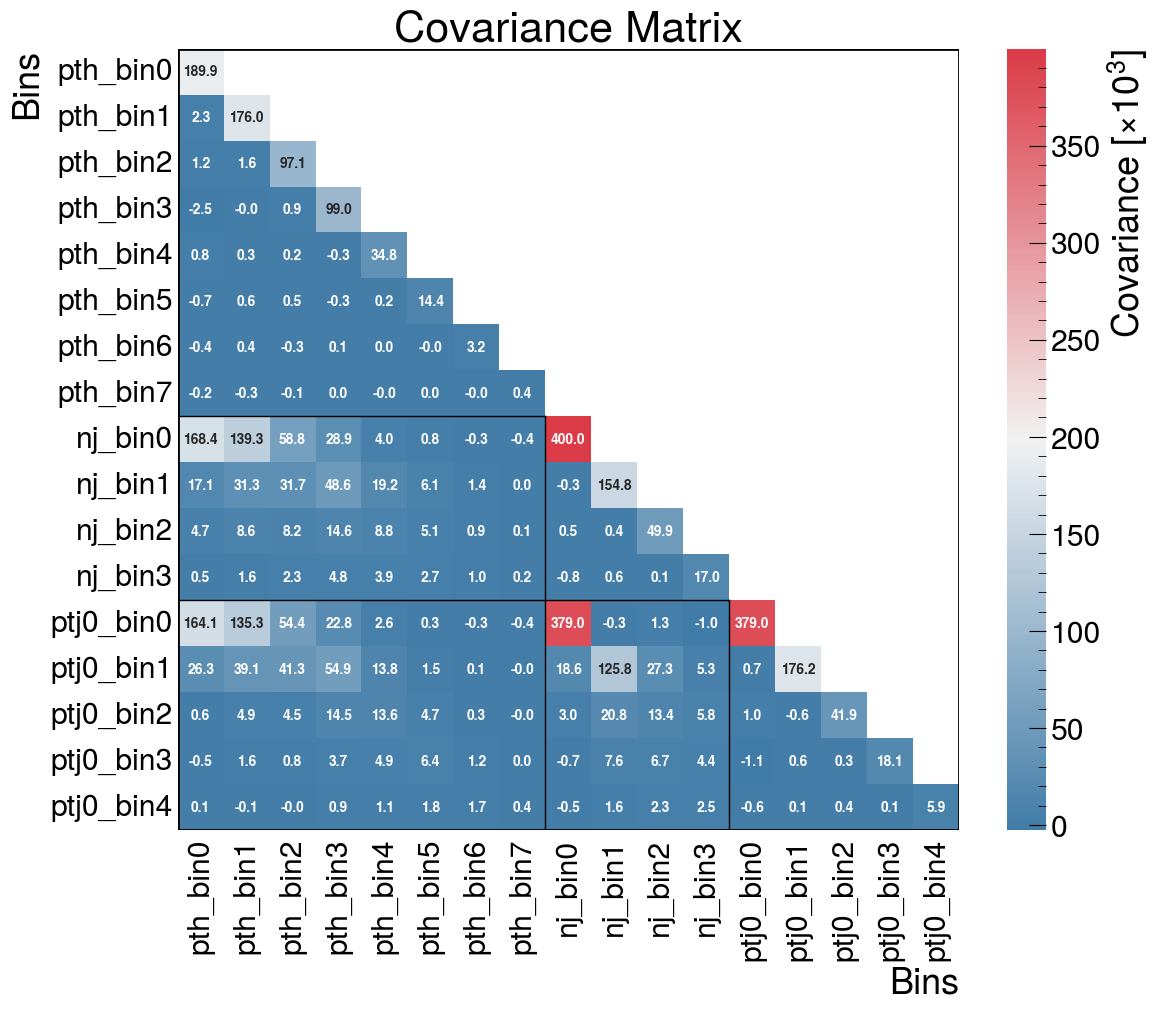

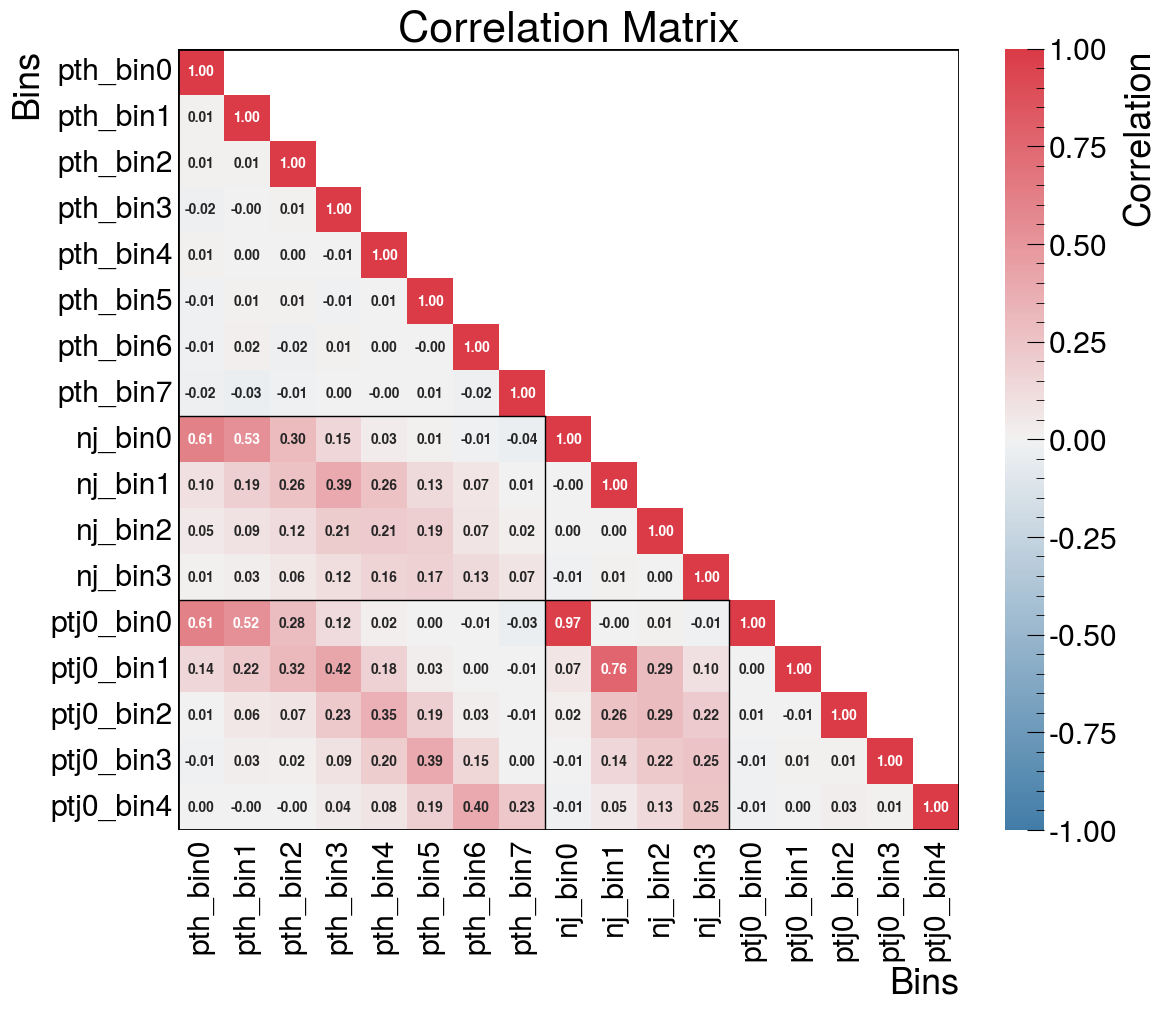

In [4]:
# Clean plotting: remove all ticks/labels, keep only block delimiters
hep.style.use("CMS")
palette = sns.diverging_palette(240, 10, n=20, as_cmap=True)

# Boundaries between variable blocks (pth | nj | ptj0)
b1 = len([c for c in df.columns if c.startswith("pth_")])
b2 = b1 + len([c for c in df.columns if c.startswith("nj_")])

# 1) Covariance matrix (scaled for readability)
cov_scale = 1e3
cov_plot = cov / cov_scale
cov_mask = np.triu(np.ones_like(cov_plot, dtype=bool), k=1)

fig_cov, ax_cov = plt.subplots(figsize=(12, 10), constrained_layout=True)
sns.heatmap(
    cov_plot,
    ax=ax_cov,
    cmap=palette,
    mask=cov_mask,
    annot=True,
    fmt=".1f",
    square=True,
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={"label": r"Covariance [$\times 10^3$]"},
)
ax_cov.set_title("Covariance Matrix")
ax_cov.set_xlabel("Bins")
ax_cov.set_ylabel("Bins")
ax_cov.tick_params(axis="x", which="both", labelrotation=90, bottom=False, top=False, length=0)
ax_cov.tick_params(axis="y", which="both", labelrotation=0, left=False, right=False, length=0)
ax_cov.minorticks_off()
n_bins = cov_plot.shape[0]
for b in (b1, b2):
    # Draw only on the visible lower triangle
    ax_cov.plot([0, b], [b, b], color="black", lw=1)
    ax_cov.plot([b, b], [b, n_bins], color="black", lw=1)
ax_cov.add_patch(Rectangle((0, 0), n_bins, n_bins, fill=False, edgecolor="black", lw=2))
plt.show()

# 2) Correlation matrix
corr_mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig_corr, ax_corr = plt.subplots(figsize=(12, 10), constrained_layout=True)
sns.heatmap(
    corr,
    ax=ax_corr,
    cmap=palette,
    mask=corr_mask,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    center=0,
    square=True,
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={"label": "Correlation"},
)
ax_corr.set_title("Correlation Matrix")
ax_corr.set_xlabel("Bins")
ax_corr.set_ylabel("Bins")
ax_corr.tick_params(axis="x", which="both", labelrotation=90, bottom=False, top=False, length=0)
ax_corr.tick_params(axis="y", which="both", labelrotation=0, left=False, right=False, length=0)
ax_corr.minorticks_off()
n_bins = corr.shape[0]
for b in (b1, b2):
    # Draw only on the visible lower triangle
    ax_corr.plot([0, b], [b, b], color="black", lw=1)
    ax_corr.plot([b, b], [b, n_bins], color="black", lw=1)
ax_corr.add_patch(Rectangle((0, 0), n_bins, n_bins, fill=False, edgecolor="black", lw=2))
plt.show()

In [5]:
def read_response_block(path: str):
    """Read response_matrix_*.txt and return numeric square block."""
    raw = pd.read_csv(path, sep=r"\s+", header=None)
    block = raw.iloc[1:, 1:].astype(float).to_numpy()
    if block.shape[0] != block.shape[1]:
        raise ValueError(f"Response block is not square for {path}: {block.shape}")
    return block

# Map covariance prefixes to the corresponding response matrix files
resp_files = {
    "ptj0": "response_matrix/response_matrix_ptJ0.txt",
    "nj": "response_matrix/response_matrix_Njets2p5.txt",
    "pth": "response_matrix/response_matrix_pth.txt",
}

# Preserve block ordering from cov (e.g. pth, nj, ptj0)
prefix_order = []
for col in cov.columns:
    pref = col.split("_", 1)[0]
    if pref not in prefix_order:
        prefix_order.append(pref)

# Build one big block-diagonal response matrix with cov labels
resp = pd.DataFrame(0.0, index=cov.index, columns=cov.columns)
start = 0
for pref in prefix_order:
    cols = [c for c in cov.columns if c.startswith(f"{pref}_")]
    n = len(cols)
    if pref not in resp_files:
        raise ValueError(f"No response matrix file configured for prefix '{pref}'")

    block = read_response_block(resp_files[pref])
    if block.shape != (n, n):
        raise ValueError(
            f"Shape mismatch for {resp_files[pref]}: got {block.shape}, expected {(n, n)}"
        )

    stop = start + n
    resp.iloc[start:stop, start:stop] = block
    start = stop

In [6]:
resp_inv = pd.DataFrame(
    np.linalg.inv(resp.to_numpy()),
    index=resp.index,
    columns=resp.columns,
)

cov_gen = resp_inv @ cov @ resp_inv.T

# Convert covariance -> correlation
sigma = np.sqrt(np.diag(cov_gen.to_numpy()))
denom = np.outer(sigma, sigma)
corr_gen_arr = np.divide(
    cov_gen.to_numpy(),
    denom,
    out=np.zeros_like(cov_gen.to_numpy()),
    where=denom != 0,
)
corr_gen = pd.DataFrame(corr_gen_arr, index=cov_gen.index, columns=cov_gen.columns)

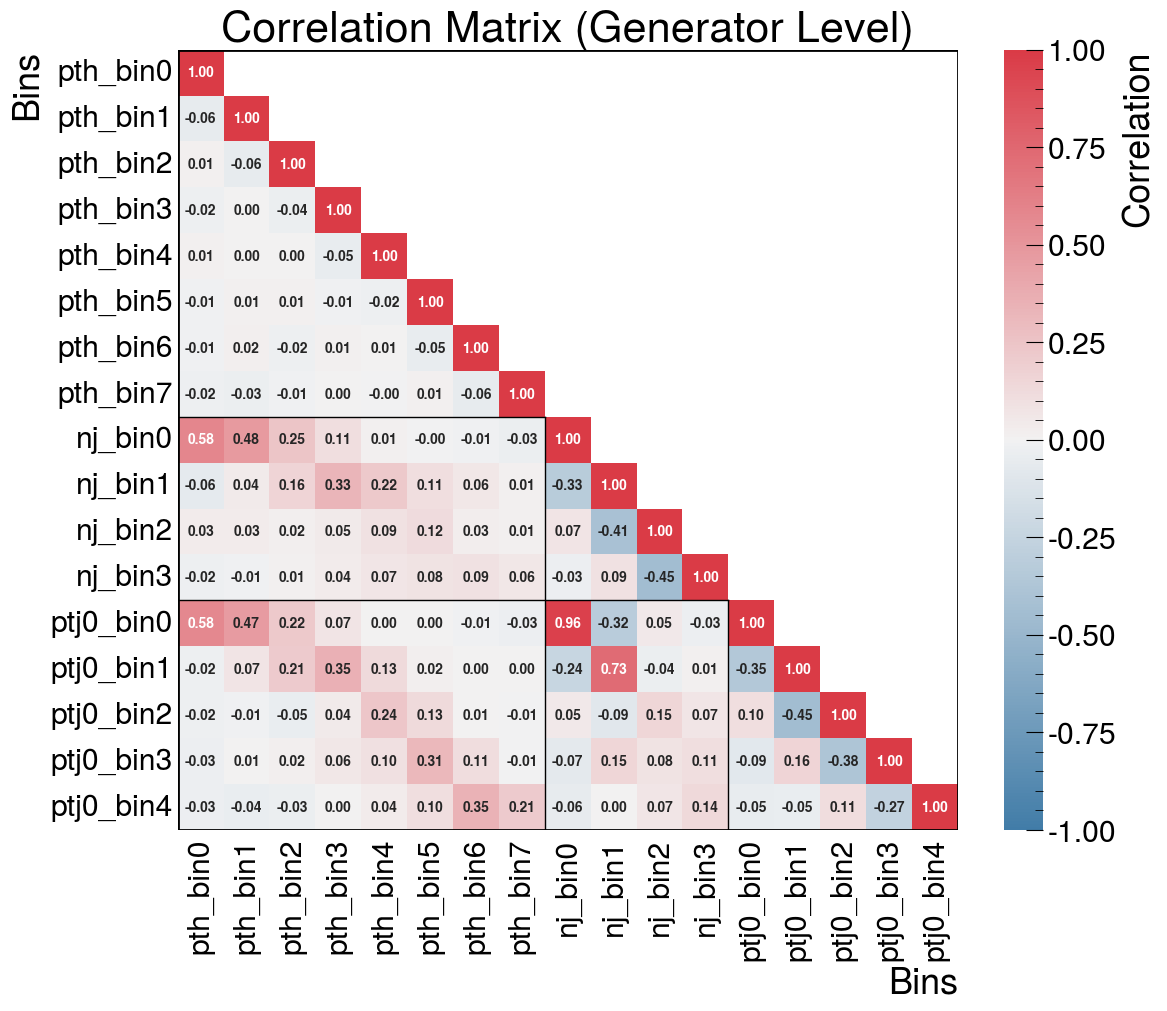

In [7]:
# Correlation matrix after response unfolding
corr_gen_mask = np.triu(np.ones_like(corr_gen, dtype=bool), k=1)
fig_corr_gen, ax_corr_gen = plt.subplots(figsize=(12, 10), constrained_layout=True)
sns.heatmap(
    corr_gen,
    ax=ax_corr_gen,
    cmap=palette,
    mask=corr_gen_mask,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    center=0,
    square=True,
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={"label": "Correlation"},
)
ax_corr_gen.set_title("Correlation Matrix (Generator Level)")
ax_corr_gen.set_xlabel("Bins")
ax_corr_gen.set_ylabel("Bins")
ax_corr_gen.tick_params(axis="x", which="both", labelrotation=90, bottom=False, top=False, length=0)
ax_corr_gen.tick_params(axis="y", which="both", labelrotation=0, left=False, right=False, length=0)
ax_corr_gen.minorticks_off()
n_bins = corr_gen.shape[0]
for b in (b1, b2):
    # Draw only on the visible lower triangle
    ax_corr_gen.plot([0, b], [b, b], color="black", lw=1)
    ax_corr_gen.plot([b, b], [b, n_bins], color="black", lw=1)
ax_corr_gen.add_patch(Rectangle((0, 0), n_bins, n_bins, fill=False, edgecolor="black", lw=2))
plt.show()